____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from swot import (
    browse_swot_250,
    add_mask_inside_swot,
    build_swath_polygon,
    browse_swot_2km,
)
from diagnosis import (
    dataset_coloc_combs,
    DRIFTER,
    ALTI,
    WD,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_mean_square,
    compute_mean_square_groupby,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

c0 = {"acc": "#941717", "cor": "#388E3C", "ggd": "#42A5F5", "wd": "#FFA000"}

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

In [19]:
dfr = pd.read_csv(DRIFTER["nofilter"], parse_dates=["datetime"], dtype=dtypes)

In [12]:
dtypes = {"drifter_id": str, "drifter_type": str}


def prepared_drifters(drifter_key, spectral_key=""):
    if spectral_key not in ["", "LF", "inertial", "diurnal", "semidiurnal", "HF"]:
        assert (
            False
        ), "spectral_key should be in  ['', 'LF', 'inertial', 'diurnal', 'semidiurnal', 'HF']"
    if spectral_key != "":
        spectral_key += "_"
    dfr = pd.read_csv(
        DRIFTER[drifter_key], parse_dates=["datetime"], dtype=dtypes
    ).set_index("row_number")
    dfr["time_to_swot"] = dfr.time_to_swot.astype("timedelta64[ns]")
    dfr["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr["core"] = -dfr.f * dfr[spectral_key + "velocity_north"]
    dfr["corn"] = dfr.f * dfr[spectral_key + "velocity_east"]
    dfr = dfr.rename(
        columns={
            spectral_key + "acceleration_north": "accn",
            spectral_key + "acceleration_east": "acce",
        }
    )
    return dfr[
        [
            "datetime",
            "longitude",
            "latitude",
            "pass_number",
            "time_to_swot",
            "cycle_number",
            "cycle_date",
            "drifter_id",
            "drifter_type",
            "accn",
            "acce",
            "core",
            "corn",
        ]
    ]

In [21]:
dfr[[v for v in dfr.columns if "acceleration_east" in v]]

,acceleration_east,HF_acceleration_east,LF_acceleration_east,inertial_acceleration_east,diurnal_acceleration_east,semidiurnal_acceleration_east
0,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
1,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
2,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004
3,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003
4,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002
...,...,...,...,...,...,...
376718,-0.000009,-0.000009,-0.000009,-0.000009,-0.000009,-0.000009
376719,-0.000007,-0.000007,-0.000007,-0.000007,-0.000007,-0.000007
376720,-0.000005,-0.000005,-0.000005,-0.000005,-0.000005,-0.000005
376721,-0.000003,-0.000003,-0.000003,-0.000003,-0.000003,-0.000003


In [8]:
comb_list = [
    dict(
        drifter_key="nofilter",
        spectral_key="LF",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    ),
    dict(
        drifter_key="nofilter",
        spectral_key="inertial",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    ),
]

DS = dataset_coloc_combs(comb_list, nearest=False)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < 12).dropna("row_number")
DSS = DS.where(DS.depth == 0, drop=True)
# DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])
DSS

/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_LF__swot2kmnaive_etaf__rio_0era5


/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_inertial__swot2kmnaive_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed


<xarray.Dataset> Size: 98MB
Dimensions:        (id_comb: 2, row_number: 150948)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 2MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 2MB 5.538 5.539 ... 2.014 2.012
    latitude       (id_comb, row_number) float64 2MB 42.31 42.31 ... 41.06 41.06
    pass_number    (id_comb, row_number) int64 2MB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 2MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) int64 2MB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 2MB '0-4351296' ... '295'
    drifter_type   (id_comb, row_number) object 2MB 'CARTHE' ... 'HEREON'
    depth          (id_comb, row_number) int64 2MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    phi            (id_comb, row_number) float64 2MB 0.2477 0.2478 ... 2.91 2.91
  * row_number     (row_number) int64 1MB 144 145 146 ... 376432 376433 376434
  * id_comb        (id_comb) <U47 376B 'nofilter_LF__swot2kmnaive_etaf__rio_0...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 2MB -2.52e-05 ... -2.54e-05
    acce           (id_comb, row_number) float64 2MB -7.881e-06 ... -8.751e-06
    exce_acc       (id_comb, row_number) float64 2MB -1.732e-05 ... -1.665e-05
    core           (id_comb, row_number) float64 2MB 1.07e-05 ... 3.582e-06
    exce_cor       (id_comb, row_number) float64 2MB -3.59e-05 ... -2.898e-05
    ggde           (id_comb, row_number) float64 2MB 9.622e-07 ... -1.727e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 2MB 4.092e-11 ... 4.212e-12
    prodn_acc_ggd  (id_comb, row_number) float64 2MB -5.829e-12 ... 4.641e-11
    prodn_acc_wd   (id_comb, row_number) float64 2MB -2.719e-11 ... 2.647e-11
    prodn_cor_ggd  (id_comb, row_number) float64 2MB -5.291e-11 ... 9.831e-12
    prodn_cor_wd   (id_comb, row_number) float64 2MB -2.468e-10 ... 5.608e-12
    prodn_ggd_wd   (id_comb, row_number) float64 2MB 3.516e-11 ... 6.179e-11

150948
6.560158637195113
6.959852294192219
6.621421151307852
6.826574478651958
5.556573808914321
5.956267465911425
5.562067794983333
5.767221122327441


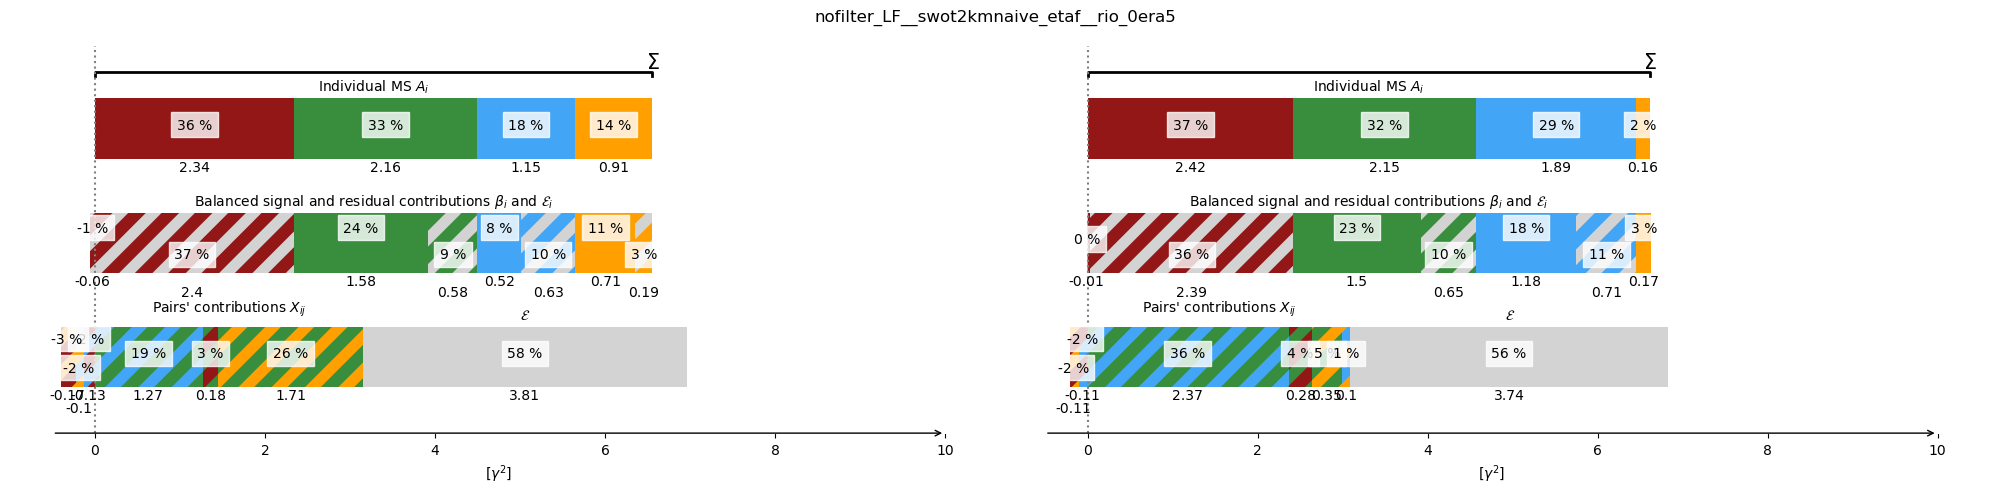

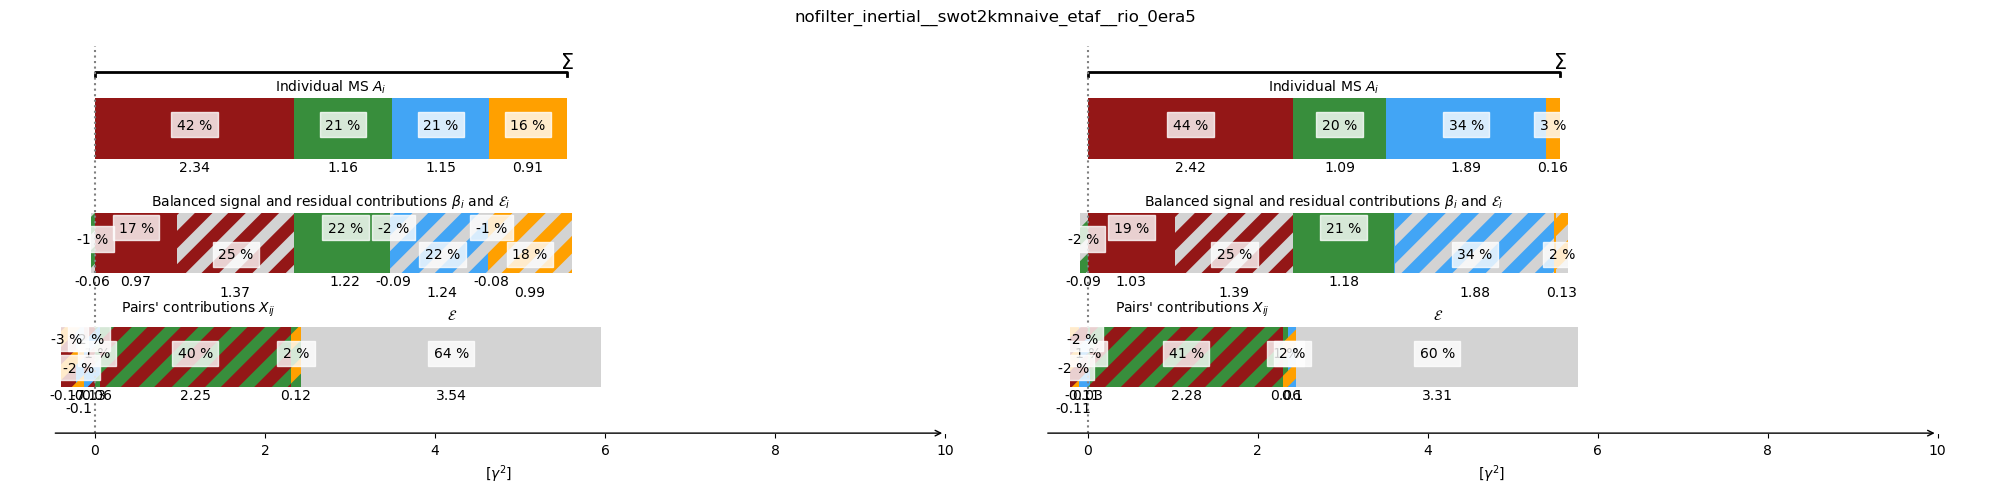

In [9]:
ds = compute_mean_square(DSS) / U2
df = ds.to_dataframe()
print(DSS.sizes["row_number"])
for c in ds.id_comb.values:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir="e", xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir="n", xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, "closure_figs", c + ".png"))